📖 **Table of Contents**

- [Problem Statement](#Problem_Statement)
- [Data Overview](#Data_Overview)
- [Exploratory Data Analysis (EDA)](#EDA)
- [Data Preprocessing](#Data_Preprocessing)
- [Model Building](#Model_Building)
- [Model Performance Evaluation](#Model_Performance_Evaluation)
- [Model Performance Improvement – Hyperparameter Tuning](#Hyperparameter_Tuning)
- [Model Comparison, Final Model Selection, and Serialization](#Model_Selection)
- [Deployment – Backend](#Backend)
- [Deployment – Frontend](#Frontend)
- [Actionable Insights and Business Recommendations](#AIBR)
- [Conclusion and Next Steps](#Conclusion)


# **[Problem Statement](#Problem_Statement)**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


## **Importing the necessary libraries**

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

#todo:Move upside
# 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np 

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi,create_repo

from sklearn.metrics import make_scorer
# To serialize the model
import joblib

# os related functionalities
import os

## **Loading the dataset**

In [2]:
#loading the csv file
data = pd.read_csv("dataset/SuperKart.csv")

In [3]:
#Creating a copy of the original data
data_original = data.copy()

# **[Data Overview](#Data_Overview)**

In [4]:
# Displaying the first five rows of the dataset
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
#Displaying the shape of the dataset
data.shape

(8763, 12)

There are total of **8763 rows** and **12 columns** in the dataset.

In [6]:
# Displaying the columns of the dataset
data.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

There are below columns in the DataSet
- Product_ID
- Product_Weight
- Product_Sugar_Content
- Product_Allocated_Area
- Product_Type
- Product_MRP
- Store_Id
- Store_Establishment_Year
- Store_Size
- Store_Location_City_Type
- Store_Type
- Product_Store_Sales_Total

In [7]:
#Checking the column data types and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


Below is the summary of the columns


| #|   Column|                     Non-Null| Count|  Dtype|  
|---|---|---|---| ---| 
| 0 |  Product_Id|                 8763| non-null|   object |
| 1 |  Product_Weight|             8763 |non-null|   float64|
 |2|   Product_Sugar_Content|      8763| non-null|   object| 
 |3 |  Product_Allocated_Area     |8763 |non-null   |float64|
 |4|   Product_Type|               8763 |non-null|   object |
 |5 |  Product_MRP                |8763 |non-null |  float64|
 |6 |  Store_Id                   |8763| non-null  | object |
 |7 |  Store_Establishment_Year   |8763| non-null   |int64  |
 |8 |  Store_Size                 |8763 |non-null   |object |
 |9 |  Store_Location_City_Type   |8763| non-null  | object |
 |10 | Store_Type                 |8763| non-null  | object |
 |11 | Product_Store_Sales_Total  |8763 |non-null  | float64|


In [8]:
#Checking the duplcate rows
data.duplicated().sum()

np.int64(0)

There are **no duplicates** in the data

In [9]:
#Checking the missing values in the data
data.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

There are no missing values in the dataset.

👉**Observation**

- There are total of 12 columns 
- *Product_Sugar_Content, Product_type, Store_Id, Store_Size, Store_Location_City_Type, Store_Type* are categorical-type variables
- Others are numerical
- Dataset doesn't have any duplicate values
- Data doesn't contain and missing values

# [Exploratory Data Analysis (EDA)](#EDA)

Defining the target and predicator(numerical and categorical) variables
- We will not consider Product_Id as its like unique identifier for a given product.

In [10]:
#Defining the target variable for the regression problem
target_variable = "Product_Store_Sales_Total"


#Listing the categorical variables
categorical_features = [
    "Product_Sugar_Content",    
    "Product_Type",    
    "Store_Id",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type"
]

#Listing the numerical variables
numerical_features = [
    "Product_Weight",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Establishment_Year"
]

## **Univariate Analysis**

In [11]:
#Generating summary for the numerical features
data[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000


So below are the statistics of the Nummerical dataset

|count|	mean|	std|	min|	25%|	50%|	75%|	max|
|---|---|---|---|---|---|---|---|
|Product_Weight	|8763.0|	12.653792|	2.217320|	4.000|	11.150|	12.660|	14.180|	22.000|
|Product_Allocated_Area	|8763.0	|0.068786	|0.048204	|0.004	|0.031	|0.056	|0.096	|0.298|
|Product_MRP|	8763.0|	147.032539|	30.694110|	31.000|	126.160|	146.740|	167.585|	266.000|
|Store_Establishment_Year|	8763.0|	2002.032751|	8.388381|	1987.000|	1998.000|	2009.000|	2009.000|	2009.000|


For the *Store_Establishment_Year* we are going to create a new feature as *age* and ust it as a numerical variable, during data-preprocessing steps.

For now lets look at each of the feature.

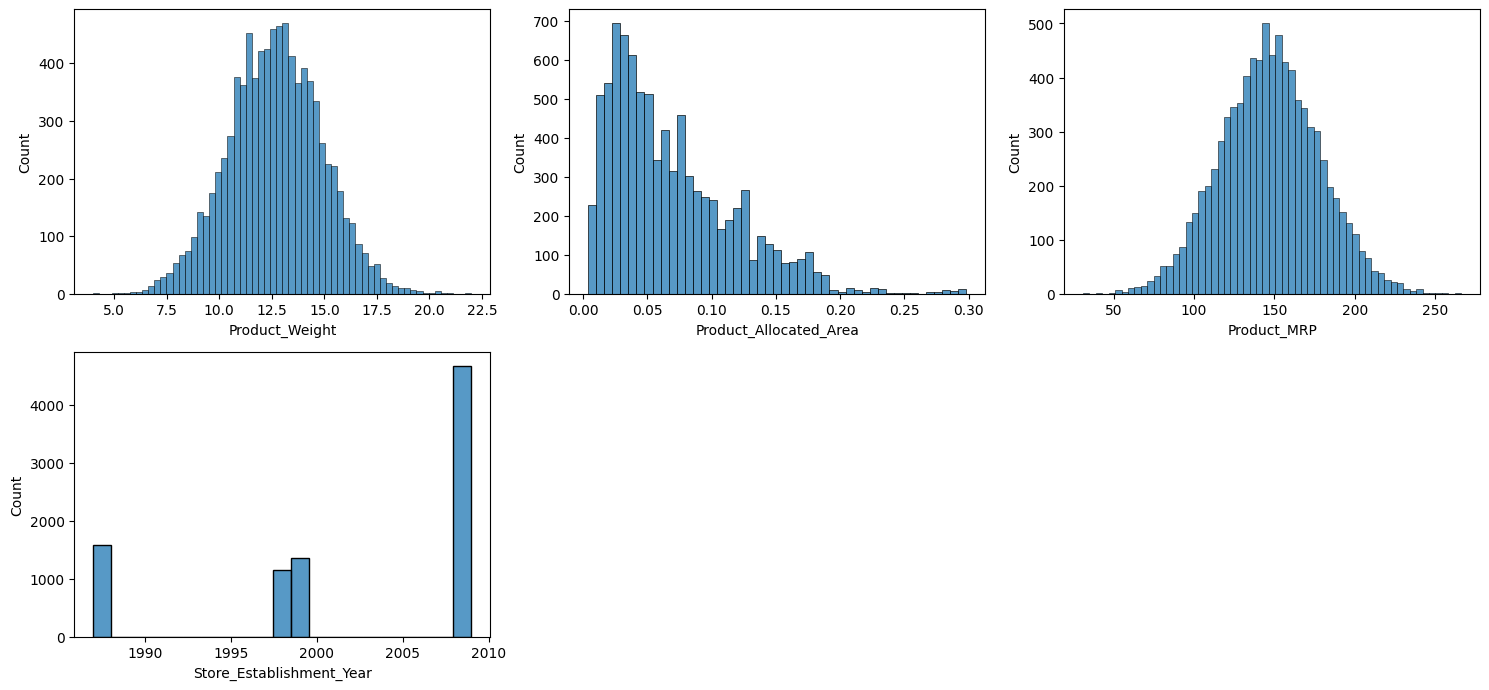

In [12]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data[numerical_features].columns.tolist()

# creating the histograms
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

👉**Observations:**

Here are the observations from the analysis

**Product Weight:**

- The distribution is approximately normal distribution
- Few values are on high side but there is no severe outliers
- This suggest most products falls within consistent weight ranges

**Product Allocated Area:**

- The distribution is *Right-skewed*
- Majority of the product take only small allocated area for the product where are few products which requires larger areas
- This is probably based on the goods which are being sold in the retail shop 

**Product MRP:**

- The product mrp is a bell shpaed curve
- Most of the products falls under 100 and 200 range with some anomalies
- The price difference can impact in the sales prediction

**Store Establishment Year:**

- There are few charts which indicates that the stores are build in a phased manner
- Seems like there are more number of new stores opened between 2005 and 2010 than before 2005
- Store age may influence customer trust and can cause impact on sales predictions 


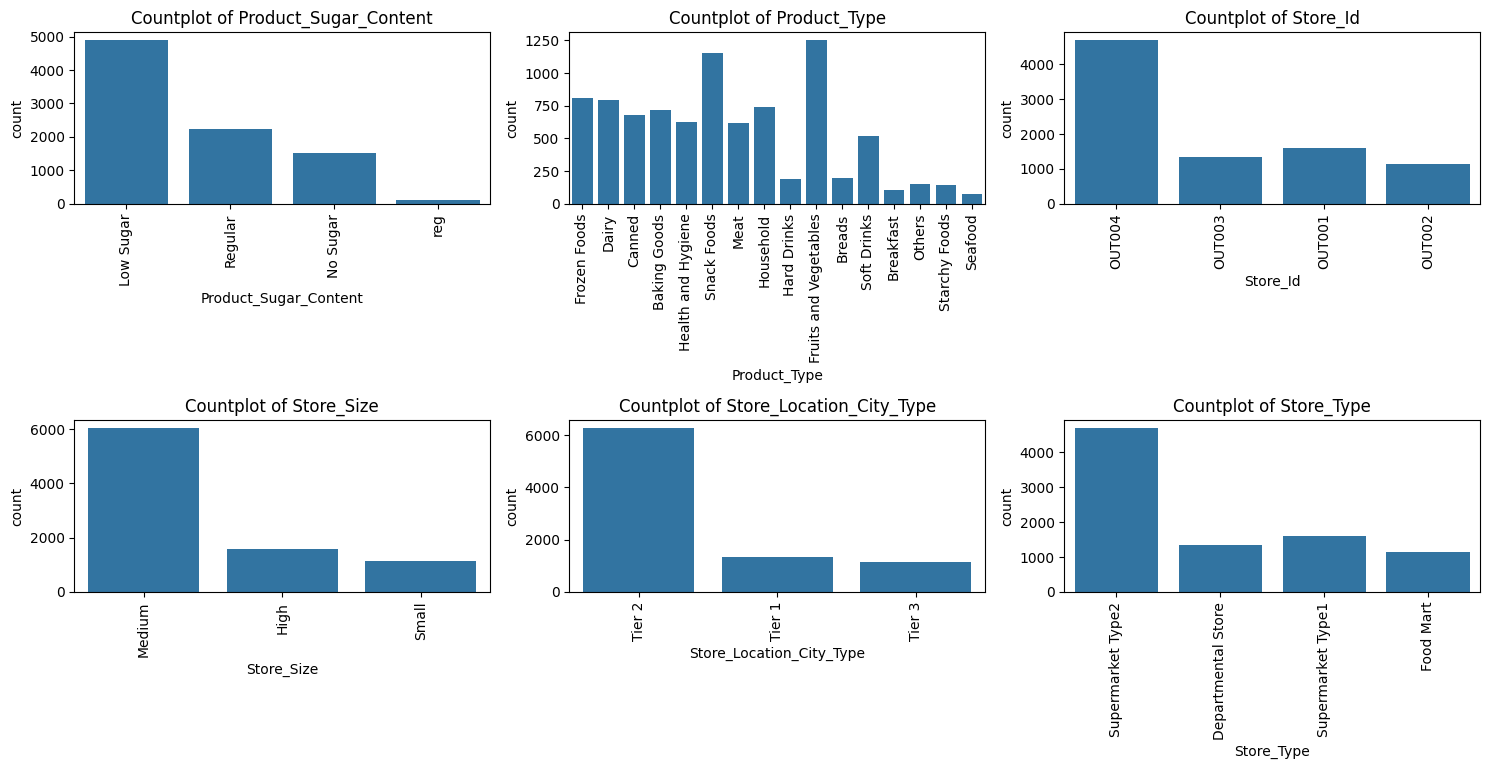

In [13]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
features = data[numerical_features].columns.tolist()

for i,col in enumerate(data[categorical_features].columns):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    # sns.histplot(data=data, x=feature)    # plot the histogram
    sns.countplot(x=data[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=90)



plt.tight_layout()    # to add spacing between plots
plt.show()


👉**Observations**

**Product Sugar Contents:**

- Majority of the products are in *Low Sugar* category
- There are few products which has been labeled as "reg" we will consolidate during pre-processing
- Sugar content could cause impact on customer preference 

**Product Type:**

- Some product types are high in numbers like *Snack Foods*, *Fruits and Vegetables*
- Ceratin food types are very low like *Seafood*, *Breakfast*
- Product Type should provide a better predictor for the prediction models

**Store Id:**

- Store *OUT004* has highest number of records
- This indicate that there is data imbalance across stores, which seems to be very real-life scenario 

**Store Size:**

- Most of the store are Medium sized stores
- Large and Small stores are few in numbers
- Store size may impact the sales volume

**Store Location City Type:**

- Most of the stores are located in *Tier 2* cities
- Tier1 and 3 has less number of stores
- Location can impact the sales as it can be linked to the purchasing power of the customer


**Store Type:**
- *Supermaket Type2* is the most common type of the stores
- Food mart has a very small number 
- Store type can impact the sales behavior



## **Bivariate Analysis**

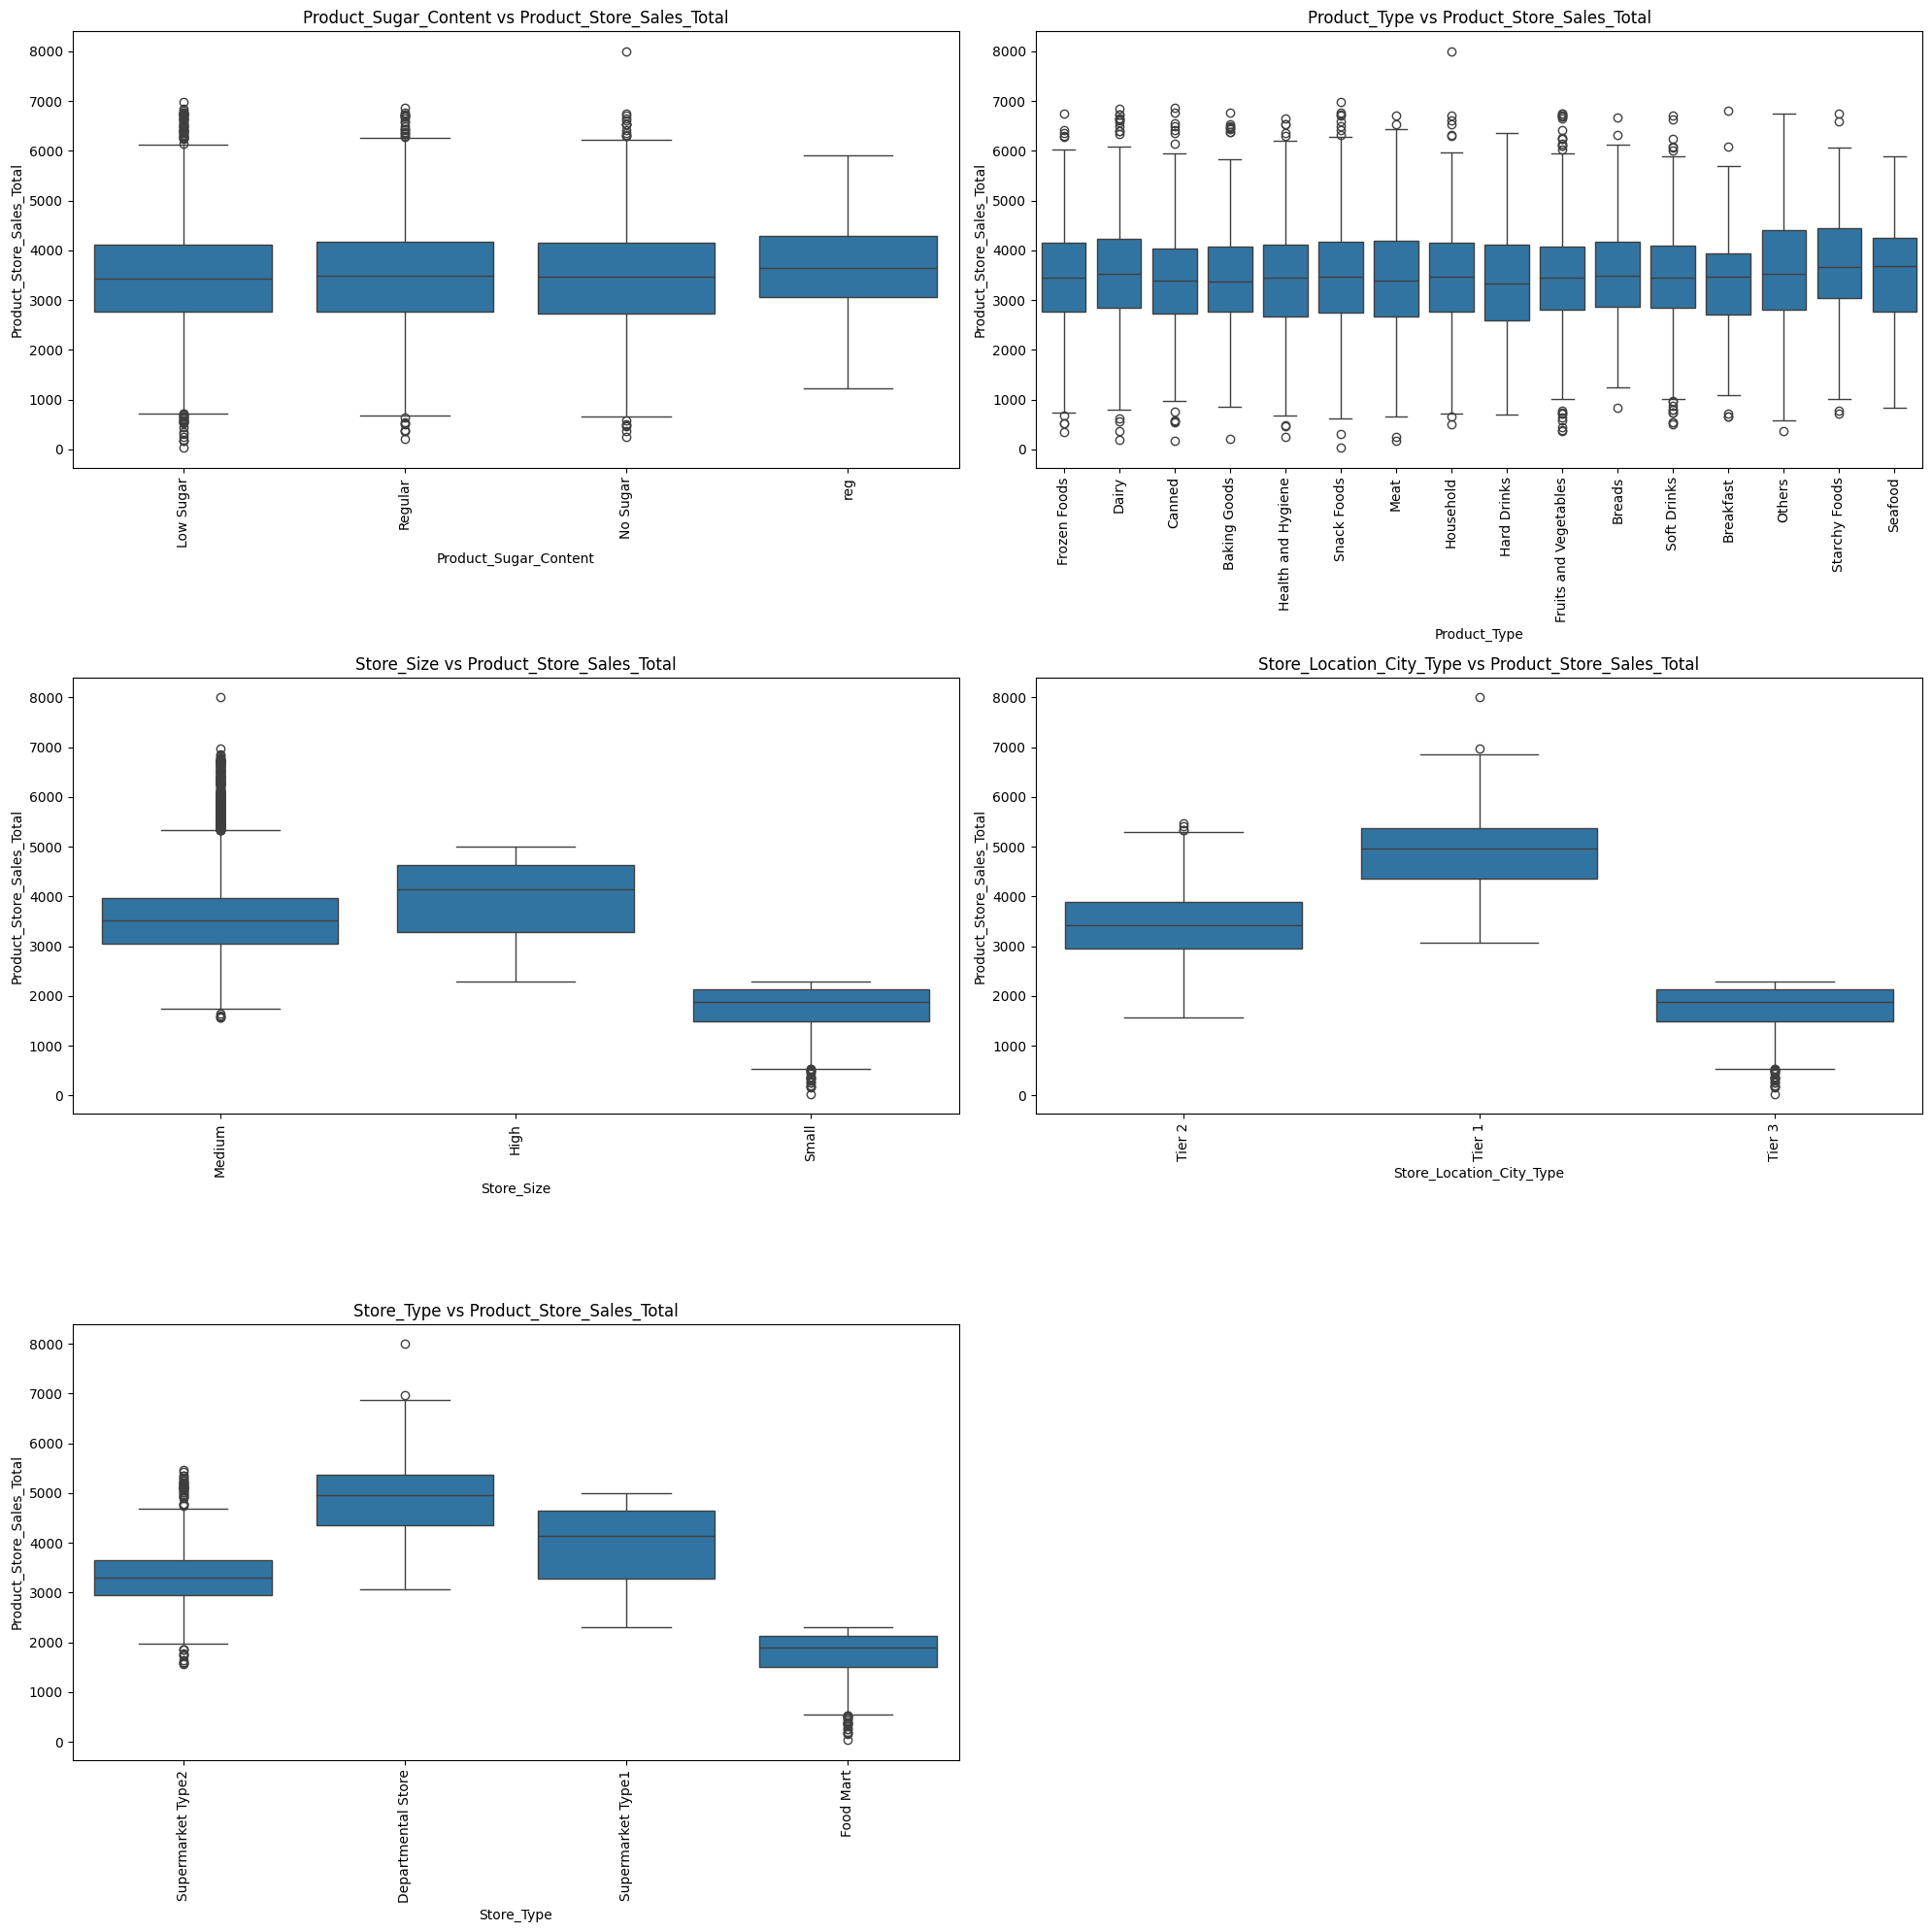

In [22]:
#Adding code for the boxplot for the target variable 

eda_categorical_features = [
    "Product_Sugar_Content",
    "Product_Type",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type"
]
plt.figure(figsize=(20, 20))
for i,col in enumerate(data[eda_categorical_features].columns):
    plt.subplot(3, 2, i+1)    # assign a subplot in the main plot
    sns.boxplot(x=data[col],y=data[target_variable], data = data)
    plt.title(f"{col} vs {target_variable}")
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Bivariate Analysis**

**Product_Sugar_Content**
- Sales distribution is almost similiar between all the categories.
- Products labeled as “Regular” and “Low Sugar” show slightly higher median sales compared to “No Sugar”.
- Sugar content alone does not appear to impact sales.

**Product_Type**
- There is difference between median of sales between the product types.
- Certain categories such as Snack Foods, Household items, and Frozen Foods show higher median sales.
- So product category can be a good feature in determing sales performance.

**Store_Size**
- Stores with **High size** exhibit the highest median sales.
- **Medium-sized stores** show mid-range sales performance.
- **Small stores** shows lower sales.
- So seems like Store size impacts sales.

**Store_Location_City_Type**
- **Tier 1 cities** have the highest median sales, followed by Tier 2 cities.
- **Tier 3 cities** show significantly lower sales distributions.
- So seems like City type is showing the purchasing power of the customer and also depicts the demand which can contribute to sales prediction.

**Store_Type**
- **Departmental Stores** show the highest median sales.
- **Supermarket Type1 and Type2** are showing less sales than *Departmental Stores* but have good sales.
- **Food Marts** have the lowest sales. This may be the food marts only have food items and the types of products are limited.


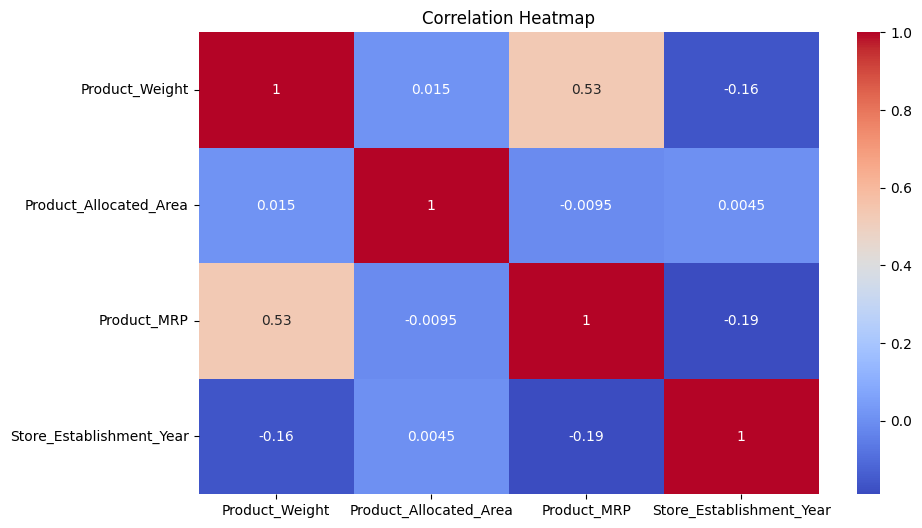

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

👉**Observations:**

- Product_Weight and Product_MRP show a **moderate positive correlation (~0.53)**, which indicates that heavier products seems to have higher MRP .
- Product_Allocated_Area shows **very little or we can say no correlation** with all other numerical variables, which indicates that allocated area doesn't have any relation with other factors.
- Store_Establishment_Year has a **weak negative correlation** with Product_MRP and Product_Weight, which shows that older stores may slightly differ in product mrp and product weight.
- Overall, we can say there is no high correlation between the numerical features which indicates **not strong collienearity** between variables.


**Key Insights from Bivariate Analysis**

1. It looks like store related features like Store_Size, Store_Type, and Store_Location_City_Type shows an impact on product sales.
2. Product_Type also plays a significant role in determining sales performance.
3. Product_Sugar_Content has not much impact than store and product category attributes, but have some impact.
4. So we are going to consider both store and product related variables for the prediction of sales.


**🔭Key Insigts from EDA**

- A small number of product categories show variation i.e. not normal distribution to overall sales.
- Store-level variables influence sales significantly, which suggests that location and store characteristics plays role in sales performance.
- Pricing and product allocation show relationships with sales, which suggests that they can be impactful for modeling and forecasting.
- So it seems like sales are influenced primarily by product category, store characteristics, and pricing-related attributes. 
- This problem is well suited for the `Supervised Regression Model`.

# **[Data Preprocessing](#Data_Preprocessing)**

Going to create a new Feature for Age of store

In [27]:
from datetime import datetime
#Creating a new feature Store_Age
current_year= datetime.today().year
data['Store_Age'] = current_year - data['Store_Establishment_Year']

#Dropping the Store_Establishment_Year column
data.drop(columns=['Store_Establishment_Year'], inplace=True)

**Feature Engineering – Store Age**

- A new feature `Store_Age` has been created using the store establishment year.
- This feature will used to understand how old a store is, which may create impact on sales numbers.

The original `Store_Establishment_Year` column has been removed to avoid redundancy and its not going to be used further.

In [28]:
#Defining the features and target variable
X = data.drop(columns=[target_variable,"Product_Id"])
y = data[target_variable]



In [29]:
#Fixing the reg to Regular in the data

data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace({
    "reg": "Regular"
})

In [30]:
#Verifying the changes
data["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

Now there are only 3 distinct values ("Low Suger", "Regular", "No Sugar")

In [31]:
RANDOM_SEED = 56
#Splitting the data into training, testing and validation sets
TESTING_SIZE = 0.2
VALIDATION_SIZE = 0.25

In [32]:
#Identifying the numerical and categorical features
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']
Categorical Features: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [33]:
#Splitting the data into training, testing and validation sets

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TESTING_SIZE, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=VALIDATION_SIZE, random_state=RANDOM_SEED) 


The dataset has been splitted into training, validation, and test sets.
- The training set will be used for model training.
- The validation set will be used for hyperparameter tuning and model selection.
- The test set will be used for final model evaluation.

**Treatment of Product Size and Price**

Although `Product_Allocated_Area` and `Product_MRP`has some skewness and the values are large, no scaling or transformation was applied.

As we are going to use tree-based models (Random Forest and Gradient Boosting), these are not sensitive to scale or distribution shape.

Additionally, there were no extreme outliers or data quality issues in these variables.


# **[Model Building](#Model_Building)**

**Evaluation Metric Selection**

🏆We are going to use *Root Mean Squared Error (RMSE)* as the evaluation metric.

As the large deviation between the actual and predicted value can create significant business impact, we would like to use RMSE(Root Mean Squared Error) which penalizes more if the prediction error is large.

**Preprocessor and Model Builing using Pipelines**

As we are going for deployment going to create a pipeline for the processes. This will make sure that processing and model building are happening properly in a pipeline way.

This will also provide a *production ready deployable* code.


Will be building two machine learning models `Random Forest` and `Gradient Boosting` as part of end-to-end pipelines that include both preprocessing and model training steps.


In [35]:
#Going to use the numeric 

#Defining the preprocessing steps for numerical and categorical features
# Numerical transformer for imputing missing values with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical transformer for imputing missing values with most frequent and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# Combining both transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numerical_transformer, numerical_features),
        ('categorical', categorical_transformer, categorical_features)
    ])


**Feature Engineering and Outlier Treatment**

- We have created a new Store_Age as a new feature. Apart from that no other pre-processing has been done
- We dont need to do explicit outlier treatment as tree-based models can work with these outliers.
- Creating a pre-processing pipeline using Pipeline and Column Transformers to handle numeric and categorical features
    - This will ensure the production ready code as this enables the use of transformation logic for all the datasets.
    - Column Transformers also make sure that relevant columns has been transformed similarly





**Define functions for Model Evaluation**

In [36]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

**Random Forest**

In [37]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=95,random_state=RANDOM_SEED))
])
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
rf_model_performance= model_performance_regression(random_forest_model, X_val, y_val)

In [39]:
rf_model_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,282.554631,108.36683,0.926138,0.925714,0.038784


| Metric                 | Value      |
| ---------------------- | ---------- |
| **RMSE**               | **282.55** |
| **MAE**                | **108.37**  |
| **R-squared**          | **0.9261** |
| **Adjusted R-squared** | **0.9257** |
| **MAPE**               | **3.87%**  |


### Random Forest Model Performance

The Random Forest model demonstrates strong predictive performance due to ensemble model.

- The RMSE value of 282.55 indicates relatively low prediction error compared to the scale of sales.
- The MAE of 108.37 shows that average prediction deviations are minimal.
- An R-squared value of 0.926 suggests that the model explains approximately 92.6% of the variance in product store sales.
- The adjusted R-squared being close to the R-squared value indicates that the model is not overfitting.
- The MAPE value of 3.87% reflects high accuracy and reliability of predictions.

Overall, the Random Forest model performs well and is suitable for further tuning and deployment.

**Gradient Boost**

In [40]:
#gradient boosting model
gradient_boosting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=RANDOM_SEED))
])
gradient_boosting_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
gb_model_performance= model_performance_regression(gradient_boosting_model, X_val, y_val)

In [42]:
gb_model_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,303.026042,133.684564,0.915048,0.91456,0.046801


| Metric                 | Value      |
| ---------------------- | ---------- |
| **RMSE**               | **303.03** |
| **MAE**                | **133.68** |
| **R-squared**          | **0.9150** |
| **Adjusted R-squared** | **0.9146** |
| **MAPE**               | **4.68%**  |


### Gradient Boosting Model Performance

The Gradient Boosting model demonstrates reasonably strong predictive performance; however, it underperforms compared to the Random Forest model.

- The RMSE of 303.03 indicates higher prediction error relative to Random Forest.
- The MAE value of 133.68 suggests larger average deviations from actual sales.
- An R-squared value of 0.915 indicates that approximately 91.5% of the variance in sales is explained by the model.
- The adjusted R-squared value being close to the R-squared value indicates stable model behavior.
- The MAPE of 4.68% reflects lower prediction accuracy compared to Random Forest.

Overall, while Gradient Boosting performs well, it is less accurate and reliable than the Random Forest model for this dataset.


# **[Model Performance Evaluation](#Model_Performance_Evaluation)**

| Metric                 | Random Forest      |Gradient Boosting|
| ---------------------- | ---------- |---|
| **RMSE**               | **282.55** |303.03|
| **MAE**                | **108.37**  |133.68|
| **R-squared**          | **0.9261** |0.9150|
| **Adjusted R-squared** | **0.9257** |0.9146|
| **MAPE**               | **3.87%**  |4.68%|


**Model Comparison and Final Selection**

Between the two models evaluated, the Random Forest model outperforms the Gradient Boosting model across all evaluation metrics.

Random Forest achieves lower RMSE and MAE values, higher R-squared scores, and significantly lower MAPE.Due to which we have better predictive accuracy, stability, and business reliability.

Therefore, the Random Forest model is selected as the final model for hyperparameter tuning, deployment, and serialization.


# **[Model Performance Improvement – Hyperparameter Tuning](#Hyperparameter_Tuning)**

**Hyperparameter Tuning**

Hyperparameter tuning is performed to further improve the performance of the models. By tuning parameters we can optimize weights and biases that can improve performance.

In [43]:
#Defining parameters to be tuned for Random Forest Regressor
paramaters_to_be_tuned = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split" :[2,5],
    "model__min_samples_leaf":[1,2]

}

In [44]:
#Define RMSE scorer for GridSearchCV
rmse_scorer = make_scorer(
    mean_squared_error,
    greater_is_better=False, #Lower RMSE is better
    squared=False
)

In [45]:
#GridSearchCV for Random Forest Regressor using pipeline

grid_search_cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_SEED))
])

In [46]:
grid_search = GridSearchCV(
    estimator=grid_search_cv_pipeline,
    param_grid=paramaters_to_be_tuned,
    scoring=rmse_scorer,
    cv=5, #number of folds
    n_jobs=-1, #use all processors
    verbose=1 
    )

In [47]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...m_state=56))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 150, ...]}"
,scoring,make_scorer(m...squared=False)
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [48]:
#Best Parameters from Grid Search
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

In [49]:
print(best_params)

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


🔭**Hyperparameter Tuning – Observations**

There is no significant improvement by doing Hyperparameter tuning over the base Random Forest model.

The parameters found by using GridSearchCV is almost same as default configuration of the Random Forest Alogrithm. Hence, the baseline model is already a good fit for the given dataset.

The absence of significant improvement after hyperparameter tuning indicates that the baseline Random Forest model is already sufficient and generalizes pretty well. This reduces the risk of overfitting of the model and increases confidence for model stability during deployment.




In [50]:
gb_model_performance= model_performance_regression(best_model, X_val, y_val)

In [51]:
gb_model_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,282.845274,108.359939,0.925986,0.925561,0.038883


| Metric                 | Value      |
| ---------------------- | ---------- |
| **RMSE**               | **282.85** |
| **MAE**                | **108.36**  |
| **R-squared**          | **0.9260** |
| **Adjusted R-squared** | **0.9256** |
| **MAPE**               | **3.89%**  |


**Model Evaluation – Best Estimator**

The `best_estimator_` from GridSearchCV is the final model that we are going to use for the model evaluation on the *Test Dataset*. Till now this dataset has not be used.

The model achieved an RMSE of approximately 282, an MAE of around 108, and an R-squared value of approximately 0.93. The adjusted R-squared value remains close to the R-squared value, indicating the absence of overfitting.



The absence of significant improvement after tuning suggests that the Random Forest model generalizes well and does not suffer from underfitting or overfitting.



# **[Model Comparison, Final Model Selection, and Serialization](#Model_Selection)**

| Model                   |Performance | RMSE       | MAE       | R-squared        | Adj. Rsquared    | MAPE (%) |
| ---------------------| --- | ---------- | --------- | ---------- | ---------- | -------- |
| Random Forest (Baseline)| ⭐⭐| **282.55** | **108.37**  | **0.9261** | **0.9257** | **3.87%** |
| Random Forest (Tuned)    |⭐⭐⭐| 282.85	| 108.36|	0.9260|	0.9256|	3.89%|
| Gradient Boosting       | ⭐| 303.03     | 133.68    | 0.9150     | 0.9146     | 4.68%    |

⭐- Less Performant
⭐⭐⭐ - Most Performant


### Model Comparison and Final Model Selection

We have done evaluation of mulitple models using RMSE, MAE, R-squared, Adjusted R-squared, and MAPE.

The Random Forest model has outperformed Gradient Boosting model in all the metrics.

Both the baseline and tuned Random Forest models have almost similar results. So it looks like that Hyperparameter tuning did not lead to a significant improvement over the baseline model. This suggest that default parameters are good for the given dataset.

Although hyperparameter tuning did not result in a different parameter configuration from the baseline Random Forest model, the tuned model used GridSearchCV which evaluated multiple options to find out the best fit parameters for models. Because of that we are going to use Tuned Random Forest as the final Model.

As tuning process has found the default configuration is the best suited, the selected model represents the best-performing and cross-validated Random Forest estimator.


🏆 - **Random Forest Tuned**

Will be using this model for deployment and testing.


In [52]:
best_rf_model_test_performance= model_performance_regression(best_model, X_test, y_test)

In [53]:
best_rf_model_test_performance

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,290.296646,105.805827,0.924983,0.924552,0.038888


In [ ]:
# End-to-end inference check using the deployed pipeline
best_model.predict(X_test[:3])

array([1809.8242, 2710.5101, 3224.8796])

**Final Model Evaluation on Test Set**

The tuned Random Forest model was evaluated on the unseen test dataset to assess its generalization capability.

- Performance on the test data is similar to that of Validation dataset.
- A R-Squared Value of 0.925 suggest that model is able to explain most of the dataset

The test set performance indicates that the model maintains strong predictive accuracy on unseen data, confirming its robustness and suitability for deployment.


🏆**Final Model Selection**

Based on validation and test set performance, the `Tuned Random Forest` model was selected as the final model.

The model demonstrated consistently lower error metrics and higher explanatory power compared to other models evaluated.


**Model Serialization**

The final trained model was serialized using the `joblib` library to enable reuse during deployment without retraining.


In [54]:
#Saving the test predictions for best model
y_test_pred = best_model.predict(X_test)

In [55]:
if not os.path.exists("backend/model"):
    os.makedirs("backend/model")
joblib.dump(best_model, "backend/model/random_forest_sales_model.joblib")


['backend/model/random_forest_sales_model.joblib']

In [57]:
# Load the saved model
loaded_model = joblib.load("backend/model/random_forest_sales_model.joblib")

# Predict using loaded model
y_test_pred_loaded = loaded_model.predict(X_test)

# Verify predictions between original and loaded model
np.allclose(y_test_pred, y_test_pred_loaded)


True

In [58]:
loaded_model.feature_names_in_


array(['Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP',
       'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type',
       'Store_Age'], dtype=object)

The serialized model was successfully reloaded and used to make predictions on the test set, confirming correct model persistence.


# **[Deployment – Backend](#Backend)**

## Flask Web Framework


In [75]:
#Creating a directory for the backend Flask API
if not os.path.exists("backend"):
    os.makedirs("backend")

In [20]:
content = """
from flask import Flask, request, jsonify
import pandas as pd
import joblib


app = Flask(__name__)

#Load the saved model
loaded_model = joblib.load("model/random_forest_sales_model.joblib")

@app.route('/')
def home():
    return "Welcome to the SuperKart Sales Prediction API!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        if not request.is_json:
            return jsonify({"error": "Request must be JSON"}), 400
        # Get the JSON data from the request
        data = request.get_json()
        
        # Convert JSON data to DataFrame
        input_data = pd.DataFrame([data])
        
        # Make prediction using the loaded model
        prediction = loaded_model.predict(input_data)
        
        # Return the prediction as JSON
        return jsonify({'prediction': round(float(prediction[0]),2)})
    except Exception as e:
        return jsonify({'error': str(e)})
    
if __name__ == '__main__':
    app.run(host='0.0.0.0', port =7860, debug=True)

"""

with open("backend/app.py", "w") as f:
    f.write(content)

## Dependencies File

In [24]:
content = """
numpy==2.0.2
pandas==2.2.2
flask==3.1.2
joblib==1.4.2
scikit-learn==1.7.2
"""

with open("backend/requirements.txt", "w") as f:
    f.write(content)


## Dockerfile

In [22]:
content = """
FROM python:3.10

WORKDIR /app

COPY requirements.txt requirements.txt

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

COPY model/ model/

EXPOSE 7860

CMD ["python", "app.py"]
"""

with open("backend/Dockerfile", "w") as f:
    f.write(content)

The flask , requirement and docker file has been created. 

%writefile is not supported in the local environment so using file writer to write the files.

## Setting up a Hugging Face Docker Space for the Backend

In [ ]:

login(token=os.environ.get("HF_TOKEN"))

In [ ]:

SPACE_NAME  = "superkart-sales-prediction-backend"  
USERNAME = "gsri24"

try:
    create_repo(
        repo_id=f"{USERNAME}/{SPACE_NAME}",
        repo_type="space",
        private=False,
        exist_ok=True,
        space_sdk="docker",
    )
    print(f"Repository '{SPACE_NAME}' created successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

/home/gaurav/miniconda/envs/riskguard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
api = HfApi()

repo_id = f"{USERNAME}/{SPACE_NAME}"

api.upload_folder(
    folder_path="backend",
    repo_id=repo_id,
    repo_type="space",
    path_in_repo=".",
    commit_message="Initial commit: Uploading backend files",
)

print("Files uploaded successfully to the Hugging Face Space.")

Files uploaded successfully to the Hugging Face Space.


A Docker-based Space has been created and all backend artifacts has been uploaded to Hugging Face.


Testing the deployed artifact

In [38]:
%%bash
curl -X POST https://gsri24-superkart-sales-prediction-backend.hf.space/predict -H "Content-Type: application/json" -d '{"Product_Weight":12.5,"Product_Sugar_Content":"Regular","Product_Allocated_Area":0.08,"Product_Type":"Snack Foods","Product_MRP":150,"Store_Id":"OUT001","Store_Size":"Medium","Store_Location_City_Type":"Tier 2","Store_Type":"Supermarket Type1","Store_Age":15}'


bash: /home/gaurav/miniconda/lib/libtinfo.so.6: no version information available (required by bash)
curl: /home/gaurav/miniconda/lib/libcurl.so.4: no version information available (required by curl)
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   288  100    28  100   260     21    200  0:00:01  0:00:01 --:--:--     0   222


{
  "prediction": 3606.75
}


Based on passed input data the prediction received from the HuggingFace api for model is 3606.75

The backend follows a `request–preprocess–predict–response` workflow, where incoming inputs are being processed and predictions is being returned via the API.


# **[Deployment – Frontend](#Frontend)**

## Streamlit for Interactive UI

In [79]:
#Creating a frontend folder for streamlit app
if not os.path.exists("frontend"):
    os.makedirs("frontend")

In [39]:
content = """
import streamlit as st
import requests

st.set_page_config(page_title="SuperKart Sales Prediction", layout="centered")
st.title("SuperKart Sales Prediction")

st.write("Enter the product and store details to predict sales.")

# Input fields for user to enter product and store details
product_weight = st.number_input("Product Weight", min_value=0.0, value=12.5)
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0,value = 0.08)
product_mrp = st.number_input("Product MRP", min_value=0.0, value=250.0)
store_establishment_year = st.number_input("Store Establishment Year", min_value=1900, max_value=2024, value=2005)
store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
store_id = st.selectbox("Store ID", ['OUT004', 'OUT003', 'OUT001', 'OUT002'])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular","No Sugar"])
product_type = st.selectbox("Product Type", ["Dairy", "Soft Drinks", "Meat", "Fruits and Vegetables", "Household", "Baking Goods", 
                                             "Snack Foods", "Breakfast", "Health and Hygiene", "Hard Drinks", "Canned", "Frozen Foods", 
                                             "Others"])
store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
store_age = 2025 - store_establishment_year

if st.button("Predict Sales"):
    # Prepare the input data in thed required format
    input_data = {
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar_content,
        "Product_Allocated_Area": product_allocated_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location_city_type,
        "Store_Type": store_type,
        "Store_Age": store_age
    }
    try:
        # Send a POST request to the API
        response = requests.post("https://gsri24-superkart-sales-prediction-backend.hf.space/predict", json=input_data)
        
        if response.status_code == 200:
            prediction = response.json().get("prediction")
            st.success(f"Predicted Sales: {prediction:.2f}")
        else:
            st.error("Error in prediction. Please try again.")
    except Exception as e:
        st.error(f"An error occurred: {str(e)}")
    # Prepare the input data in the required format
"""

with open("frontend/app.py", "w") as f:
    f.write(content)

## Dependencies File

In [ ]:
content = """
streamlit==1.52.2
requests==2.32.3
numpy==2.0.2
pandas==2.2.2
"""

with open("frontend/requirements.txt", "w") as f:
    f.write(content)

## DockerFile

In [36]:
content = """
FROM python:3.10

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 7860 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

"""

with open("frontend/Dockerfile", "w") as f:
    f.write(content)

The above streamlit based app has been installed and it is working fine inside local environment.

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
USERNAME = "gsri24"   
SPACE_NAME = "superkart-sales-frontend"

try:
    create_repo(
        repo_id=f"{USERNAME}/{SPACE_NAME}",
        repo_type="space",
        space_sdk="docker",
        private=False
    )
    print("Frontend Streamlit Space created")
except Exception as e:
    if "RepositoryAlreadyExistsError" in str(e):
        print("Space already exists, continuing...")
    else:
        raise e


Frontend Streamlit Space created


In [ ]:
api = HfApi()

repo_id = f"{USERNAME}/{SPACE_NAME}"

api.upload_folder(
    folder_path="frontend",   # local path
    repo_id=repo_id,
    repo_type="space",
)

print("Frontend uploaded successfully")


Frontend uploaded successfully


![alt text](image.png)

The Code has been migrated to HuggingFace and it is working

# **[Actionable Insights and Business Recommendations](#AIBR)**

## **Actionable Insights from the Analysis**

- Sales are not evenly distributed across all product categories. A few categories shows a larger share of overall sales, while some categories depict steady volume but with less sales. This suggests differences in pricing, demand, or customer preference across categories.

- Store-level analysis indicates that certain stores perform significantly better than others. These variations are likely influenced by factors such as store location, customer and city type.

- From the modeling results, it is evident that only a subset of features plays a major role in influencing predictions. This implies that SuperKart’s sales outcomes are driven by a few high-impact factors, while other variables contribute marginally.

## **Business Recommendations**



- **Category-focused planning:** SuperKart can prioritize inventory planning and promotional efforts around high-performing categories to maximize revenue, while re-evaluating pricing and promotion strategies for categories that generate volume but lower value.

- **Store-specific decision making:** Need to evaluate high-performing stores to understand operational efficiency or practices that may be replicated across other locations. For stores with lower performance, targeted strategies with promotions in local area and keeping better inventory may help improve results.

- **Improved demand forecasting:** Since sales patterns show consistency, the deployed machine learning model can be used to support demand forecasting and inventory planning, helping reduce issues such as overstocking or unavailability.

- **Operational focus on key drivers:** By identifying the most influential factors affecting sales, SuperKart can focus on monitoring and decision-making efforts on those variables which can help in simplifying operations cost while increasing effectiveness.



**Final Recommendataion:** To enhance the business impact for Superkart `category-level optimization` and `demand forecasting` should be considered as key driving features for higher sales and growth of business.



# **[Conclusion and Next Steps](#Conclusion)**

## **Conclusion**


In this project, an end-to-end machine learning solution was developed for SuperKart, covering data exploration, preprocessing, model building, evaluation, and deployment.
Exploratory data analysis helped identify key patterns related to product categories, store performance, and pricing behavior. Based on these insights, multiple machine learning models were built and evaluated using appropriate regression metrics.

Among the models evaluated, the Random Forest model demonstrated the best overall performance in terms of accuracy, stability, and generalization. Hyperparameter tuning confirmed that the baseline configuration was already well-suited for the dataset, indicating a robust and reliable model.

The final model was successfully serialized and deployed using a Flask backend and Streamlit frontend on Hugging Face, enabling end-to-end inference in a production-like environment.


## **Next Steps**

While the current solution meets the project requirements and is deployment-ready, the following steps can be considered for future improvements:

- **Incorporating additional features:** Including external factors such as seasonal trends, promotions, or regional demand indicators could further improve predictive performance.

- **Continuous model monitoring:** As new sales data becomes available, tracking model performance over time can help detect data drift and maintain accuracy.

- **Automated retraining pipeline:** Setting up periodic retraining workflows would ensure the model remains up to date with changing business patterns.

- **Scalability and optimization:** For large-scale usage, the deployment can be extended with better request handling, logging, and performance optimization.